# 01 - Data Exploration
Looking at the raw ManyThings.org English-Spanish pairs before any cleaning.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("../data/raw/spa.txt", sep="\t", header=None, names=["english", "spanish", "metadata"], encoding="utf-8")
data = data[["english", "spanish"]]
data.head(10)

,english,spanish
0,Go.,Ve.
1,Go.,Vete.
2,Go.,Vaya.
3,Go.,Váyase.
4,Go.,Id.
5,Go.,Vayan.
6,Go.,Váyanse.
7,Hi.,Hola.
8,Run!,¡Corre!
9,Run!,¡Corran!


## Basic stats

In [2]:
print("Total pairs:", len(data))
print("Missing values:\n", data.isnull().sum())
print("Duplicate rows:", data.duplicated().sum())

Total pairs: 144215
Missing values:
 english    0
spanish    0
dtype: int64
Duplicate rows: 0


## Sentence length distribution

In [3]:
data["english_length"] = data["english"].apply(lambda x: len(x.split()))
data["spanish_length"] = data["spanish"].apply(lambda x: len(x.split()))
data[["english_length", "spanish_length"]].describe()

,english_length,spanish_length
count,144215.000000,144215.000000
mean,6.203016,5.965808
std,2.593682,2.744990
min,1.000000,1.000000
25%,4.000000,4.000000
50%,6.000000,6.000000
75%,8.000000,7.000000
max,70.000000,68.000000


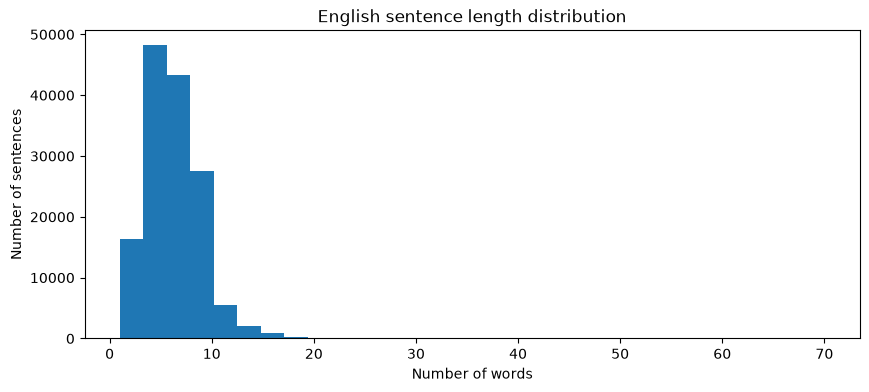

In [4]:
plt.figure(figsize=(10, 4))
plt.hist(data["english_length"], bins=30)
plt.xlabel("Number of words")
plt.ylabel("Number of sentences")
plt.title("English sentence length distribution")
plt.show()

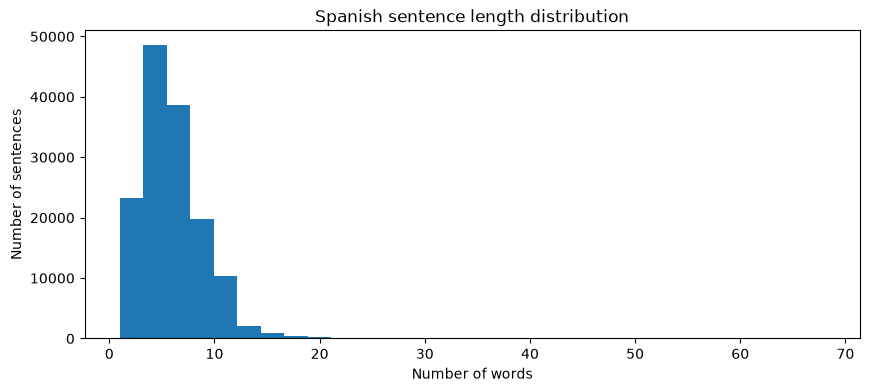

In [5]:
plt.figure(figsize=(10, 4))
plt.hist(data["spanish_length"], bins=30)
plt.xlabel("Number of words")
plt.ylabel("Number of sentences")
plt.title("Spanish sentence length distribution")
plt.show()

## Sample a few pairs

In [6]:
data.sample(10, random_state=55)

,english,spanish,english_length,spanish_length
72463,Mary is absolutely beautiful.,Mary es absolutamente hermosa.,4,4
16120,You look so pale.,Te ves tan pálido.,4,4
112159,Is this the latest model cash register?,¿Es este el último modelo de caja registradora?,7,8
29483,Do you eat out often?,¿Comes afuera a menudo?,5,4
37717,Tom deserves a reward.,Tom merece una recompensa.,4,4
6172,Just take one.,Cojan solo una.,3,3
33886,You catch on quickly.,Captás rápido.,4,2
10944,Is this a river?,¿Es ese un río?,4,4
131251,He gave us an essay to write during the vacation.,Nos mandó escribir una redacción para las vaca...,10,8
46440,I'm a little bit hungry.,Tengo un poquito de hambre.,5,5


Cleaning, filtering, splitting, and vocab-building happen in `02_data_preprocessing.ipynb`.